In [1]:
# STUDENT NAME: VIKAASAN S
# STUDENT ROLL NO: 24BAD129

!pip -q install transformers datasets huggingface_hub kagglehub matplotlib pandas scikit-learn tensorflow pillow

import os
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow version: 2.21.0
GPU: []


In [2]:
# DOWNLOAD KAGGLE DATASET

import kagglehub

# Kaggle Cat/Dog dataset
KAGGLE_DATASET = "tongpython/cat-and-dog"

print("Downloading Kaggle dataset...")
KAGGLE_PATH = kagglehub.dataset_download(KAGGLE_DATASET)

print("Dataset downloaded to:")
print(KAGGLE_PATH)

print("\nFiles/folders:")
for item in os.listdir(KAGGLE_PATH)[:20]:
    print(item)


c:\Users\Vikasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 218M/218M [00:30<00:00, 7.38MB/s] 

Extracting files...


Dataset downloaded to:
C:\Users\Vikasan\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1

Files/folders:
test_set
training_set


In [3]:
# FIND THE DATASET DIRECTORY AUTOMATICALLY

def find_image_root(base_path):
    # Look for folders named cats/dogs first
    candidates = []

    for root, dirs, files in os.walk(base_path):
        lower_dirs = {d.lower() for d in dirs}
        if "cats" in lower_dirs and "dogs" in lower_dirs:
            return root

    # Otherwise find a directory containing at least two image-containing folders
    for root, dirs, files in os.walk(base_path):
        image_dirs = []
        for d in dirs:
            dpath = os.path.join(root, d)
            count = 0
            for _, _, fs in os.walk(dpath):
                count += sum(
                    f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
                    for f in fs
                )
            if count > 0:
                image_dirs.append(d)

        if len(image_dirs) >= 2:
            candidates.append(root)

    if candidates:
        return candidates[0]

    return base_path


DATASET_DIR = find_image_root(KAGGLE_PATH)

print("Detected dataset directory:")
print(DATASET_DIR)

print("\nContents:")
for item in os.listdir(DATASET_DIR):
    print(item)


Detected dataset directory:
C:\Users\Vikasan\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1\test_set\test_set

Contents:
cats
dogs


In [4]:
# CREATE IMAGE PATHS AND LABELS

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
    and not d.startswith(".")
])

# Prefer only actual class folders
class_names = [
    d for d in class_names
    if any(
        f.lower().endswith(VALID_EXTENSIONS)
        for _, _, files in os.walk(os.path.join(DATASET_DIR, d))
        for f in files
    )
]

print("Classes:", class_names)

file_paths = []
labels = []

for label, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)

    for root, _, files in os.walk(class_dir):
        for file in files:
            if file.lower().endswith(VALID_EXTENSIONS):
                file_paths.append(os.path.join(root, file))
                labels.append(label)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total images:", len(file_paths))

for i, name in enumerate(class_names):
    print(f"{name}: {(labels == i).sum()} images")


Classes: ['cats', 'dogs']
Total images: 2023
cats: 1011 images
dogs: 1012 images


In [5]:
# OPTIONAL: LIMIT DATASET SIZE FOR FASTER VS CODE TRAINING

# Set MAX_IMAGES_PER_CLASS = None to use the complete dataset.
MAX_IMAGES_PER_CLASS = 1000

selected_paths = []
selected_labels = []

for label in range(len(class_names)):
    indices = np.where(labels == label)[0]

    if MAX_IMAGES_PER_CLASS is not None:
        indices = indices[:MAX_IMAGES_PER_CLASS]

    selected_paths.extend(file_paths[indices])
    selected_labels.extend(labels[indices])

file_paths = np.array(selected_paths)
labels = np.array(selected_labels)

print("Images used:", len(file_paths))


Images used: 2000


In [6]:
# SPLIT INTO TRAINING, VALIDATION AND TESTING SETS

# 70% training, 15% validation, 15% testing

X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))


Training images: 1400
Validation images: 300
Testing images: 300


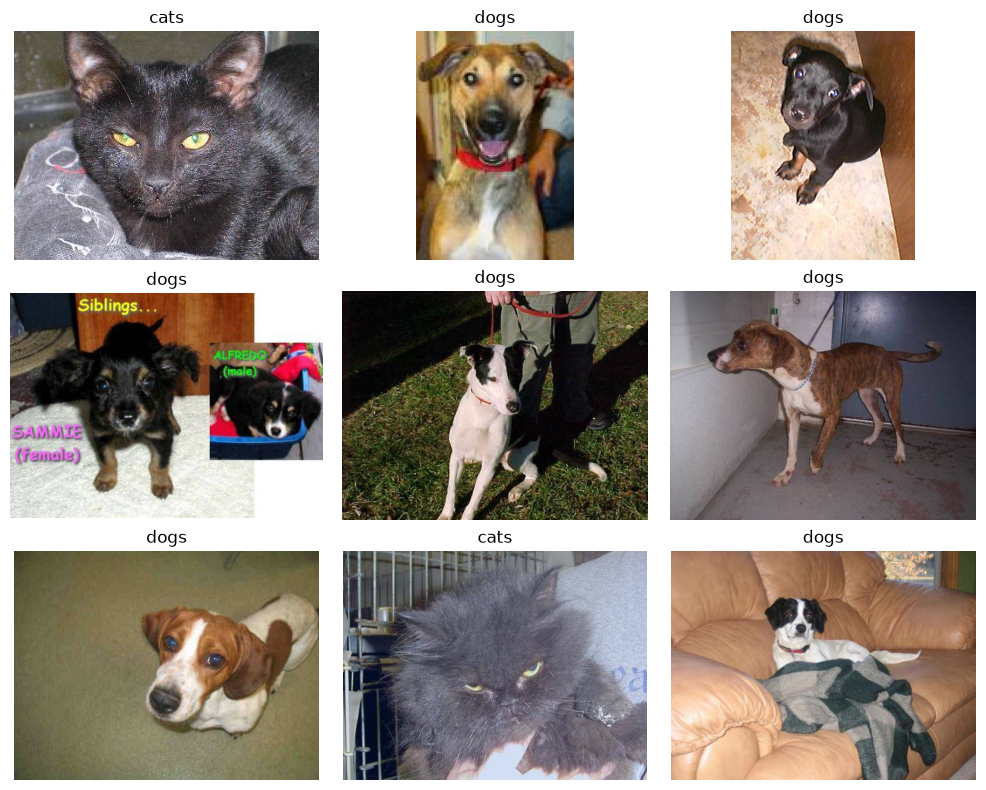

In [7]:
# DISPLAY SAMPLE IMAGES

plt.figure(figsize=(10, 8))

for i in range(min(9, len(X_train))):
    image = Image.open(X_train[i]).convert("RGB")

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
# IMAGE PREPROCESSING

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # ResNet-50 preprocessing
    image = preprocess_input(image)

    return image, label


def make_dataset(paths, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

print("Datasets created successfully.")


Datasets created successfully.


In [9]:
# LOAD PRE-TRAINED RESNET-50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze feature extraction layers
base_model.trainable = False

print("ResNet-50 loaded successfully.")
print("Base model trainable:", base_model.trainable)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
ResNet-50 loaded successfully.
Base model trainable: False


In [10]:
# BUILD TRANSFER-LEARNING MODEL

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.30),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
# TRAIN THE TRANSFER-LEARNING MODEL

EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/5


c:\Users\Vikasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


44/44 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9564 - loss: 0.1193 - val_accuracy: 0.9767 - val_loss: 0.0630
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9857 - loss: 0.0425 - val_accuracy: 0.9767 - val_loss: 0.0711
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.9843 - loss: 0.0424 - val_accuracy: 0.9833 - val_loss: 0.0449
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9886 - loss: 0.0320 - val_accuracy: 0.9867 - val_loss: 0.0503
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9957 - loss: 0.0108 - val_accuracy: 0.9867 - val_loss: 0.0409


In [12]:
# EVALUATE ON TEST DATA

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.9900 - loss: 0.0463
Test Loss     : 0.0463
Test Accuracy : 0.9900


In [13]:
# RECORD TRAINING AND VALIDATION RESULTS

results_df = pd.DataFrame({
    "Epoch": range(1, len(history.history["accuracy"]) + 1),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

display(results_df)


,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,0.956429,0.976667,0.119260,0.062956
1,2,0.985714,0.976667,0.042479,0.071141
2,3,0.984286,0.983333,0.042412,0.044874
3,4,0.988571,0.986667,0.031964,0.050278
4,5,0.995714,0.986667,0.010843,0.040885


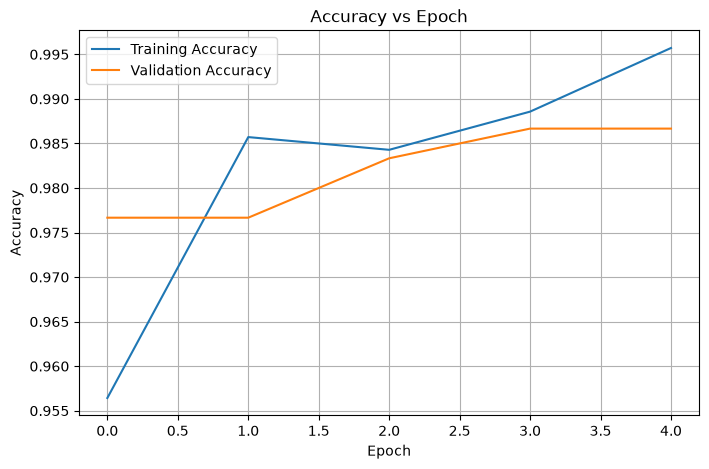

In [14]:
# ACCURACY VS EPOCH

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


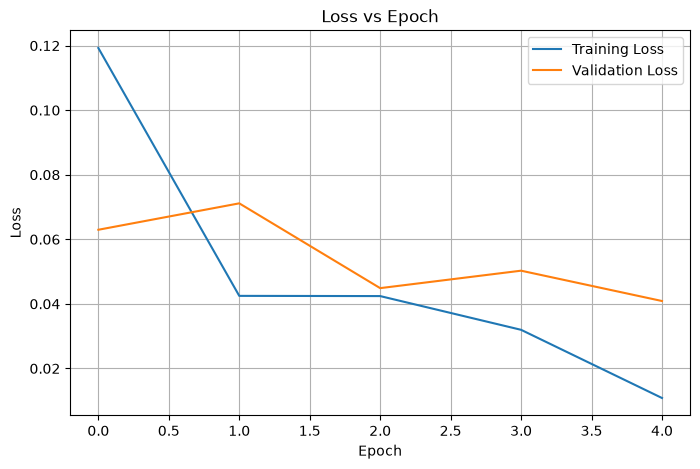

In [15]:
# LOSS VS EPOCH

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


Classification Report:
              precision    recall  f1-score   support

        cats       0.99      0.99      0.99       150
        dogs       0.99      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



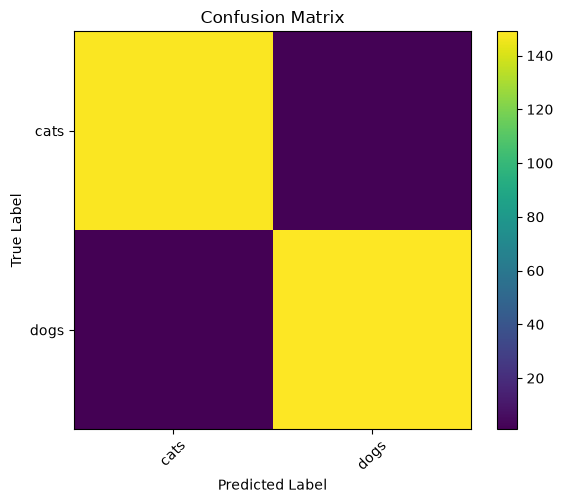

In [16]:
# CLASSIFICATION REPORT AND CONFUSION MATRIX

y_true = []
y_pred = []

for images, labels_batch in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()
plt.tight_layout()
plt.show()
